In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import torch
from torch.utils.data import DataLoader

from dataset import SceneTwoPairsDataset
from model import PairImageCylinderModel
from losses import supervised_loss


In [3]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: True
NVIDIA GeForce RTX 5050 Laptop GPU


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PairImageCylinderModel(
    img_size=128,
    patch_size=16,
    in_chans=3,
    embed_dim=256,
    depth=4,
    num_heads=4,
    num_bins=32,
    dropout=0.1,
).to(device)

In [5]:
from torch.utils.data import DataLoader

dataset = SceneTwoPairsDataset(
    root_dir="dataset",
    image_size=128,
    scale_xy=2.8,
    return_paths=False,
)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
)

In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

model.train()
for epoch in range(100):
    total = 0.0

    for batch in loader:
        img_a, vision_a, img_b, vision_b, pose_ab = batch

        img_a = img_a.to(device, non_blocking=True)
        img_b = img_b.to(device, non_blocking=True)
        vision_a = vision_a.to(device, non_blocking=True)
        pose_ab = pose_ab.to(device, non_blocking=True)

        pred_vision, pred_pose = model(img_a, img_b)

        loss, loss_vis, loss_pose = supervised_loss(
            pred_vision, vision_a,
            pred_pose, pose_ab,
            lambda_pose=1.0,
        )

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total += loss.item()

    print(f"Epoch {epoch+1}: loss={total / len(loader):.4f}")

Epoch 1: loss=2.2353
Epoch 2: loss=2.1716
Epoch 3: loss=1.8585
Epoch 4: loss=1.9664
Epoch 5: loss=1.7352
Epoch 6: loss=2.2862
Epoch 7: loss=2.0868
Epoch 8: loss=2.2117
Epoch 9: loss=1.8077
Epoch 10: loss=2.1765
Epoch 11: loss=2.3715
Epoch 12: loss=2.1591
Epoch 13: loss=1.8404
Epoch 14: loss=1.8321
Epoch 15: loss=1.9534
Epoch 16: loss=2.1595
Epoch 17: loss=1.8528
Epoch 18: loss=1.9165
Epoch 19: loss=2.0294
Epoch 20: loss=2.0460
Epoch 21: loss=2.1144
Epoch 22: loss=1.9378
Epoch 23: loss=2.0398
Epoch 24: loss=1.8691
Epoch 25: loss=1.9382
Epoch 26: loss=2.1614
Epoch 27: loss=1.7747
Epoch 28: loss=2.1186
Epoch 29: loss=2.0730
Epoch 30: loss=1.7779
Epoch 31: loss=2.0367
Epoch 32: loss=2.0682
Epoch 33: loss=2.1425
Epoch 34: loss=2.3063
Epoch 35: loss=2.0898
Epoch 36: loss=1.9342
Epoch 37: loss=2.0542
Epoch 38: loss=1.9475
Epoch 39: loss=2.2837
Epoch 40: loss=1.9755
Epoch 41: loss=1.8299
Epoch 42: loss=2.2457
Epoch 43: loss=1.9481
Epoch 44: loss=1.8415
Epoch 45: loss=1.9441
Epoch 46: loss=1.93

Sample 0
  GT   pose: tx=0.487, ty=0.000, yaw=0.0°
  Pred pose: tx=0.028, ty=-0.001, yaw=0.9°
  |err|     : tx=0.459, ty=0.001, sin=0.015, cos=0.000

Sample 1
  GT   pose: tx=0.268, ty=0.000, yaw=0.0°
  Pred pose: tx=0.028, ty=-0.001, yaw=0.9°
  |err|     : tx=0.239, ty=0.001, sin=0.015, cos=0.000

Sample 2
  GT   pose: tx=0.149, ty=0.000, yaw=0.0°
  Pred pose: tx=0.028, ty=-0.001, yaw=0.9°
  |err|     : tx=0.121, ty=0.001, sin=0.015, cos=0.000

Sample 3
  GT   pose: tx=-0.199, ty=0.000, yaw=0.0°
  Pred pose: tx=0.028, ty=-0.001, yaw=0.9°
  |err|     : tx=0.228, ty=0.001, sin=0.015, cos=0.000



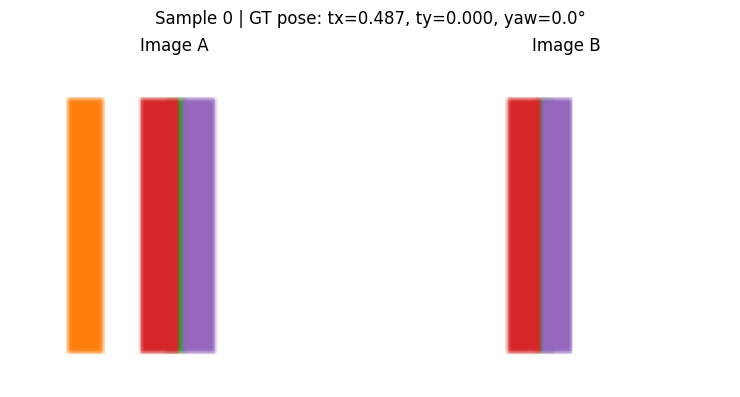

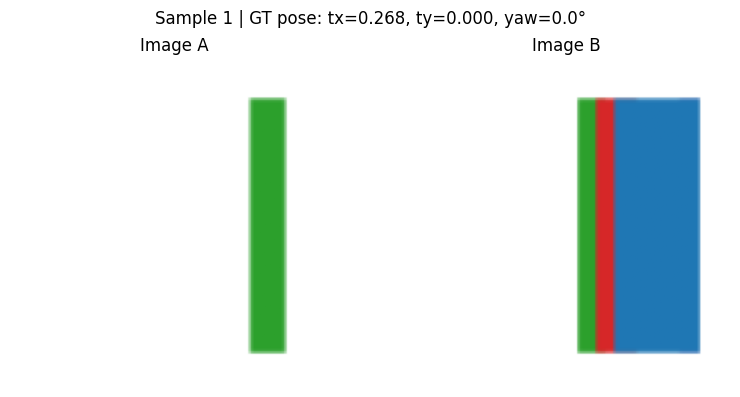

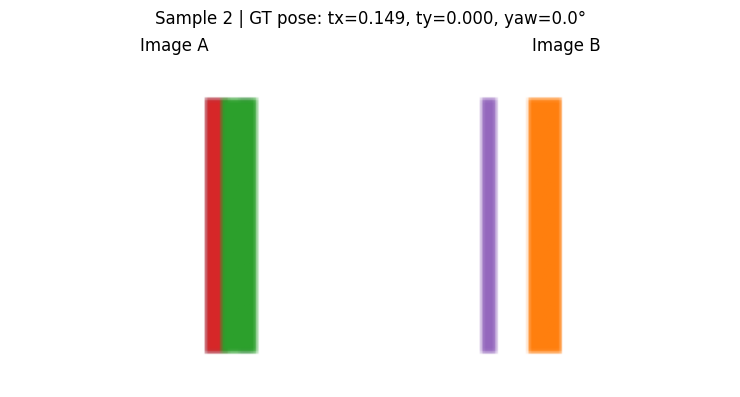

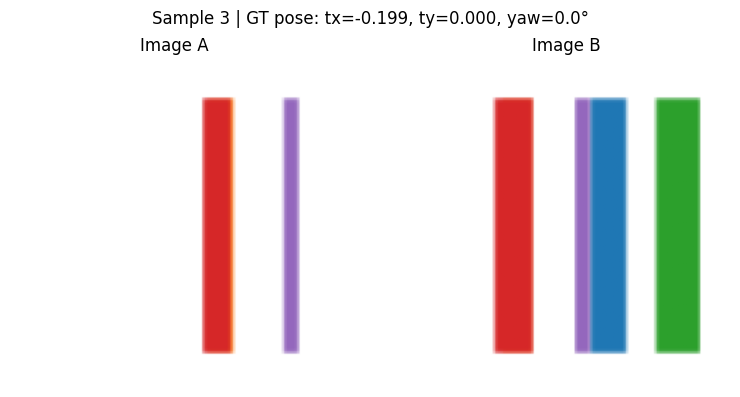

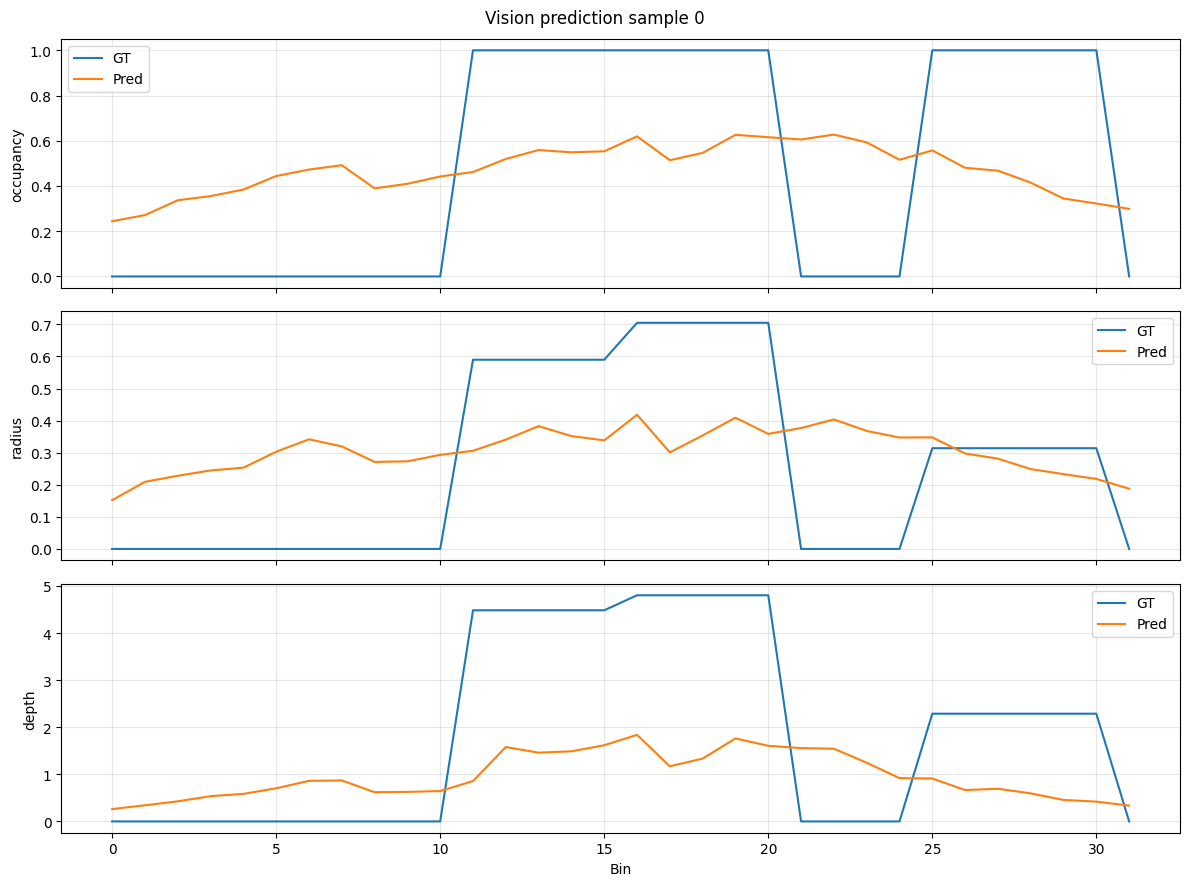

In [10]:
# Inference + utskrift + plottar på samma dataset som träningen
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Samma dataset som i träningen, men utan shuffle för stabil visualisering
infer_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
)

def pose_to_text(pose_4):
    """
    pose_4: tensor [tx, ty, sin(yaw), cos(yaw)]
    """
    tx, ty, s, c = pose_4.tolist()
    yaw_deg = np.degrees(np.arctan2(s, c))
    return f"tx={tx:.3f}, ty={ty:.3f}, yaw={yaw_deg:.1f}°"

def show_image_pair(img_a, img_b, title=None):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_a.permute(1, 2, 0).cpu().clamp(0, 1))
    axes[0].set_title("Image A")
    axes[0].axis("off")

    axes[1].imshow(img_b.permute(1, 2, 0).cpu().clamp(0, 1))
    axes[1].set_title("Image B")
    axes[1].axis("off")

    if title is not None:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

model.eval()

batch = next(iter(infer_loader))
img_a, vision_a, img_b, vision_b, pose_ab = batch

img_a = img_a.to(device)
vision_a = vision_a.to(device)
img_b = img_b.to(device)
vision_b = vision_b.to(device)
pose_ab = pose_ab.to(device)

with torch.no_grad():
    pred_vision, pred_pose = model(img_a, img_b)

# Skriv ut resultat för några samples
n_show = min(4, img_a.shape[0])
for i in range(n_show):
    print(f"Sample {i}")
    print("  GT   pose:", pose_to_text(pose_ab[i].detach().cpu()))
    print("  Pred pose:", pose_to_text(pred_pose[i].detach().cpu()))

    pose_err = torch.abs(pred_pose[i] - pose_ab[i]).detach().cpu()
    print(f"  |err|     : tx={pose_err[0]:.3f}, ty={pose_err[1]:.3f}, sin={pose_err[2]:.3f}, cos={pose_err[3]:.3f}")
    print()

# Plotta bildpar
for i in range(n_show):
    show_image_pair(
        img_a[i].detach().cpu(),
        img_b[i].detach().cpu(),
        title=f"Sample {i} | GT pose: {pose_to_text(pose_ab[i].detach().cpu())}"
    )

# Plotta vision-output för första samplet
sample_idx = 0
bins = np.arange(pred_vision.shape[1])

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

names = ["occupancy", "radius", "depth"]
for j, ax in enumerate(axes):
    gt = vision_a[sample_idx, :, j].detach().cpu().numpy()
    pr = pred_vision[sample_idx, :, j].detach().cpu().numpy()

    ax.plot(bins, gt, label="GT")
    ax.plot(bins, pr, label="Pred")
    ax.set_ylabel(names[j])
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Bin")
fig.suptitle(f"Vision prediction sample {sample_idx}")
plt.tight_layout()
plt.show()